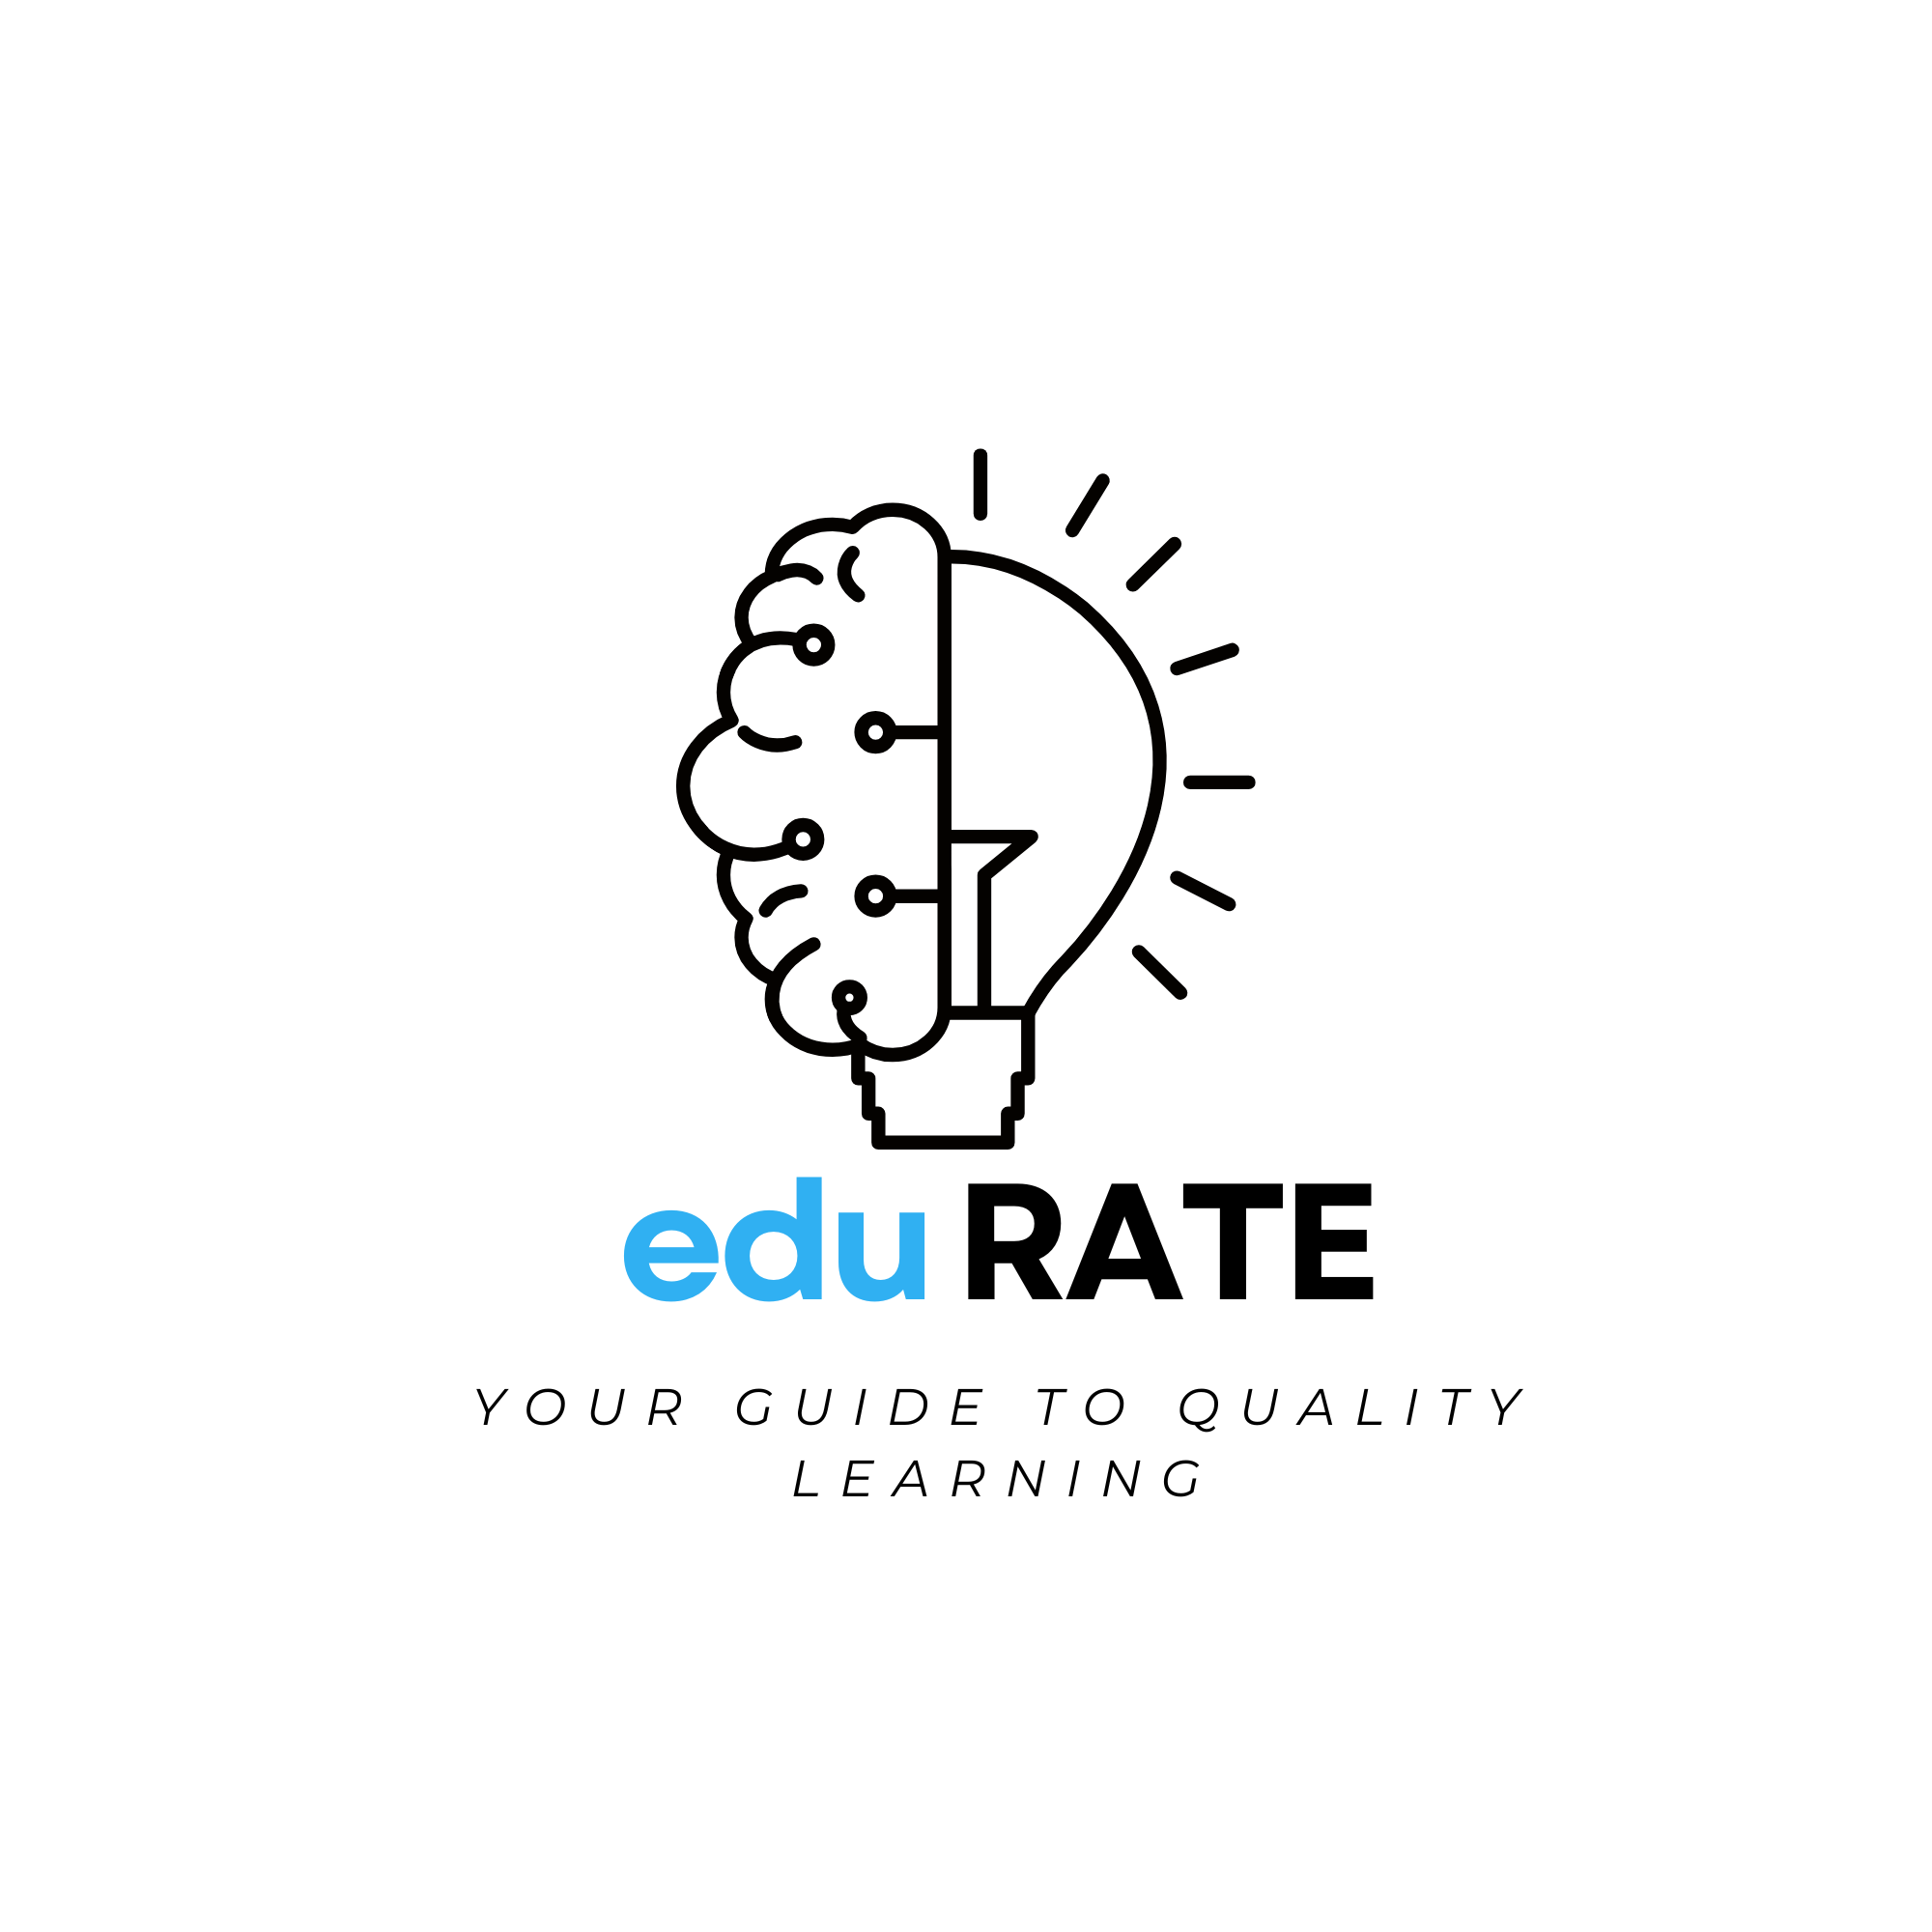

**Recommendation System Feature For The Universities**

In [ ]:
'''
Description For This Feature:
This notebook is for developing the recommendation system feature for edu Rate project
The recommendation system has the task of making individualized suggestions that assist students to pick appropriate universities and professors. The system accepts as an input data on user preferences, ratings and data on interaction (searches and selections) as well as on structured data on universities and professors. According to this information, the system produces the result in the form of the suggested universities and professors which correspond to interests and behavior of the user. This characteristic helps students to have less effort to do in order to search through various options and lead them to more relevant ones. The recommendation process must be effective, scalable, and flexible to user behavior in the long run. This system should be able to use the available data continuously to enhance the quality of recommendations and offer a more personal user experience.
'''

'\nDescription For This Feature:\nThis notebook is for developing the recommendation system feature for edu Rate project\nThe recommendation system has the task of making individualized suggestions that assist students to pick appropriate universities and professors. The system accepts as an input data on user preferences, ratings and data on interaction (searches and selections) as well as on structured data on universities and professors. According to this information, the system produces the result in the form of the suggested universities and professors which correspond to interests and behavior of the user. This characteristic helps students to have less effort to do in order to search through various options and lead them to more relevant ones. The recommendation process must be effective, scalable, and flexible to user behavior in the long run. This system should be able to use the available data continuously to enhance the quality of recommendations and offer a more personal us

# Importing Neccessary Libraries

In [8]:
# Libraries Needed for developing the recommendation system
!pip install scikit-fuzzy

In [9]:
# Importing them
import numpy as np
import skfuzzy as fuzz

# Data Samples From The Database

In [14]:
# Testing Data
universities = [
    {
        "UniversityId": 1,
        "Name": "HTU",
        "Location": "Amman",
        "Description": "Technology-focused university in Jordan",
        "WebsiteUrl": "https://www.htu.edu.jo",
        "IsDeleted": False,
        "Majors": ["AI", "CS", "Cyber Security"],
        "Levels": ["Bachelor", "Diploma"],
        "BudgetLevel": 5,
        "Ranking": 5
    },
    {
        "UniversityId": 2,
        "Name": "University of Jordan",
        "Location": "Amman",
        "Description": "Large public university in Jordan",
        "WebsiteUrl": "https://www.ju.edu.jo",
        "IsDeleted": False,
        "Majors": ["AI", "CS", "Engineering", "Medicine"],
        "Levels": ["Bachelor", "Diploma"],
        "BudgetLevel": 3,
        "Ranking": 4
    },
    {
        "UniversityId": 3,
        "Name": "PSUT",
        "Location": "Amman",
        "Description": "Private university specialized in technology and engineering",
        "WebsiteUrl": "https://www.psut.edu.jo",
        "IsDeleted": False,
        "Majors": ["AI", "CS", "Data Science", "Cyber Security"],
        "Levels": ["Bachelor"],
        "BudgetLevel": 8,
        "Ranking": 5
    },
    {
        "UniversityId": 4,
        "Name": "Yarmouk University",
        "Location": "Irbid",
        "Description": "Public university located in northern Jordan",
        "WebsiteUrl": "https://www.yu.edu.jo",
        "IsDeleted": False,
        "Majors": ["CS", "Engineering", "Business"],
        "Levels": ["Bachelor", "Diploma"],
        "BudgetLevel": 2,
        "Ranking": 4
    },
    {
        "UniversityId": 5,
        "Name": "German Jordanian University",
        "Location": "Madaba",
        "Description": "University focused on applied sciences and German academic model",
        "WebsiteUrl": "https://www.gju.edu.jo",
        "IsDeleted": False,
        "Majors": ["CS", "Engineering", "Business", "Design"],
        "Levels": ["Bachelor"],
        "BudgetLevel": 7,
        "Ranking": 4
    }
]

# Functions

In [19]:
# Functions For the scores
# Location Match Score Function
def location_match_score(user_city, university_location, distance_sensitivity):
    same_location = user_city.lower() == university_location.lower()
    if same_location:
        return 10
    if distance_sensitivity == "Low":
        return 7
    elif distance_sensitivity == "Medium":
        return 4
    elif distance_sensitivity == "High":
        return 1
    return 0

# Major Match Score Function
def major_match_score(preferred_major, university_majors):
    preferred_major = preferred_major.lower()
    for major in university_majors:
        if preferred_major == major.lower():
            return 10
    return 0

# Level Match Score Function
def level_match_score(level_of_study, university_levels):
    level_of_study = level_of_study.lower()
    for level in university_levels:
        if level_of_study == level.lower():
            return 10
    return 0

# Budget Match Score Function
def budget_match_score(user_budget_sensitivity, university_budget_level):
    """
    Budget Level Score Meaning:
    0 = very cheap
    10 = very expensive

    Budget Sensitivity Meaning:
    Low = student does not care about cost
    Medium = student prefers reasonable cost
    High = student strongly prefers cheap universities
    """
    if user_budget_sensitivity == "Low":
        return 10
    if user_budget_sensitivity == "Medium":
        return max(0, 10 - abs(university_budget_level - 5))
    if user_budget_sensitivity == "High":
        return max(0, 10 - university_budget_level)
    return 0

# Ranking Match Score Function
def ranking_match_score(preferred_ranking, university_ranking):
    """
    Ranking is from 1 to 5.
    Converted to a fuzzy score from 0 to 10.
    """
    difference = abs(preferred_ranking - university_ranking)
    return max(0, 10 - difference * 2.5)

In [20]:
# The fuzzy recommendation function
def fuzzy_university_score(
    major_score,
    level_score,
    location_score,
    budget_score,
    ranking_score
):
    x_input = np.arange(0, 11, 1)
    x_recommendation = np.arange(0, 101, 1)

    low = fuzz.trimf(x_input, [0, 0, 5])
    medium = fuzz.trimf(x_input, [0, 5, 10])
    high = fuzz.trimf(x_input, [5, 10, 10])

    poor = fuzz.trimf(x_recommendation, [0, 0, 50])
    good = fuzz.trimf(x_recommendation, [25, 50, 75])
    excellent = fuzz.trimf(x_recommendation, [50, 100, 100])

    major_high = fuzz.interp_membership(x_input, high, major_score)
    major_low = fuzz.interp_membership(x_input, low, major_score)

    level_high = fuzz.interp_membership(x_input, high, level_score)

    location_high = fuzz.interp_membership(x_input, high, location_score)
    location_medium = fuzz.interp_membership(x_input, medium, location_score)
    location_low = fuzz.interp_membership(x_input, low, location_score)

    budget_high = fuzz.interp_membership(x_input, high, budget_score)
    budget_medium = fuzz.interp_membership(x_input, medium, budget_score)
    budget_low = fuzz.interp_membership(x_input, low, budget_score)

    ranking_high = fuzz.interp_membership(x_input, high, ranking_score)
    ranking_medium = fuzz.interp_membership(x_input, medium, ranking_score)
    ranking_low = fuzz.interp_membership(x_input, low, ranking_score)

    # Rule 1:
    # IF major is high AND level is high AND ranking is high
    # THEN recommendation is excellent
    rule1 = np.fmin(
        np.fmin(major_high, level_high),
        ranking_high
    )
    activation_excellent_1 = np.fmin(rule1, excellent)

    # Rule 2:
    # IF major is high AND budget is high AND location is high
    # THEN recommendation is excellent
    rule2 = np.fmin(
        np.fmin(major_high, budget_high),
        location_high
    )
    activation_excellent_2 = np.fmin(rule2, excellent)

    # Rule 3:
    # IF major is high AND ranking is medium
    # THEN recommendation is good
    rule3 = np.fmin(major_high, ranking_medium)
    activation_good_1 = np.fmin(rule3, good)

    # Rule 4:
    # IF major is high AND location is medium AND budget is medium
    # THEN recommendation is good
    rule4 = np.fmin(
        np.fmin(major_high, location_medium),
        budget_medium
    )
    activation_good_2 = np.fmin(rule4, good)

    # Rule 5:
    # IF major is low
    # THEN recommendation is poor
    rule5 = major_low
    activation_poor_1 = np.fmin(rule5, poor)

    # Rule 6:
    # IF location is low AND budget is low AND ranking is low
    # THEN recommendation is poor
    rule6 = np.fmin(
        np.fmin(location_low, budget_low),
        ranking_low
    )
    activation_poor_2 = np.fmin(rule6, poor)

    aggregated = np.fmax(
        activation_poor_1,
        np.fmax(
            activation_poor_2,
            np.fmax(
                activation_good_1,
                np.fmax(
                    activation_good_2,
                    np.fmax(
                        activation_excellent_1,
                        activation_excellent_2
                    )
                )
            )
        )
    )

    if aggregated.sum() == 0:
        return 0

    recommendation_score = fuzz.defuzz(
        x_recommendation,
        aggregated,
        "centroid"
    )
    return float(round(recommendation_score, 2))

In [21]:
# The Main Recommendation Function
def recommend_universities(user_input, universities):
    results = []
    for uni in universities:
        if uni["IsDeleted"]:
            continue
        major_score = major_match_score(
            user_input["preferred_major"],
            uni["Majors"]
        )
        level_score = level_match_score(
            user_input["level_of_study"],
            uni["Levels"]
        )
        location_score = location_match_score(
            user_input["city"],
            uni["Location"],
            user_input["distance_sensitivity"]
        )
        budget_score = budget_match_score(
            user_input["budget_sensitivity"],
            uni["BudgetLevel"]
        )
        ranking_score = ranking_match_score(
            user_input["preferred_ranking"],
            uni["Ranking"]
        )
        final_score = fuzzy_university_score(
            major_score,
            level_score,
            location_score,
            budget_score,
            ranking_score
        )
        results.append({
            "UniversityId": uni["UniversityId"],
            "UniversityName": uni["Name"],
            "Location": uni["Location"],
            "Description": uni["Description"],
            "WebsiteUrl": uni["WebsiteUrl"],
            "RecommendationScore": final_score,
            "MajorScore": major_score,
            "LevelScore": level_score,
            "LocationScore": location_score,
            "BudgetScore": budget_score,
            "RankingScore": round(ranking_score, 2)
        })
    results.sort(
        key=lambda x: x["RecommendationScore"],
        reverse=True
    )
    return results

In [22]:
# Example For Testing
user_input = {
    "city": "Amman",
    "preferred_major": "AI",
    "level_of_study": "Bachelor",
    "distance_sensitivity": "High",
    "budget_sensitivity": "Medium",
    "preferred_ranking": 5
}
recommendations = recommend_universities(user_input, universities)
for rec in recommendations:
    print(rec)

{'UniversityId': 1, 'UniversityName': 'HTU', 'Location': 'Amman', 'Description': 'Technology-focused university in Jordan', 'WebsiteUrl': 'https://www.htu.edu.jo', 'RecommendationScore': 83.33, 'MajorScore': 10, 'LevelScore': 10, 'LocationScore': 10, 'BudgetScore': 10, 'RankingScore': 10.0}
{'UniversityId': 3, 'UniversityName': 'PSUT', 'Location': 'Amman', 'Description': 'Private university specialized in technology and engineering', 'WebsiteUrl': 'https://www.psut.edu.jo', 'RecommendationScore': 83.33, 'MajorScore': 10, 'LevelScore': 10, 'LocationScore': 10, 'BudgetScore': 7, 'RankingScore': 10.0}
{'UniversityId': 2, 'UniversityName': 'University of Jordan', 'Location': 'Amman', 'Description': 'Large public university in Jordan', 'WebsiteUrl': 'https://www.ju.edu.jo', 'RecommendationScore': 66.93, 'MajorScore': 10, 'LevelScore': 10, 'LocationScore': 10, 'BudgetScore': 8, 'RankingScore': 7.5}
{'UniversityId': 4, 'UniversityName': 'Yarmouk University', 'Location': 'Irbid', 'Description'